In [1]:
import io
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, HuberRegressor

In [2]:
data = pd.read_csv(io.StringIO("""Day,Price
1,NaN
2,NaN
3,1800
4,1900
5,NaN
6,NaN
7,2000
8,2200"""))

In [3]:
data.dtypes

Day        int64
Price    float64
dtype: object

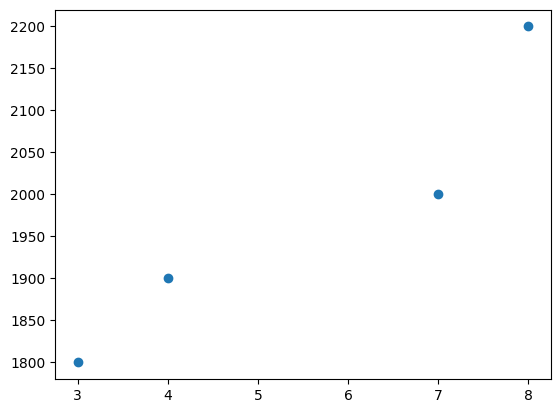

In [4]:
fig, axe = plt.subplots()
axe.scatter(data["Day"], data["Price"])

In [5]:
q = data["Price"].isnull()

In [6]:
model = LinearRegression(fit_intercept=True)
model = HuberRegressor()

In [7]:
model.fit(data.loc[~q, ["Day"]], data.loc[~q, "Price"])

HuberRegressor()

In [8]:
data.loc[q, "Price"] = model.predict(data.loc[q, ["Day"]])

In [9]:
data

,Day,Price
0,1,1657.262196
1,2,1732.916292
2,3,1800.000000
3,4,1900.000000
4,5,1959.878581
5,6,2035.532678
6,7,2000.000000
7,8,2200.000000


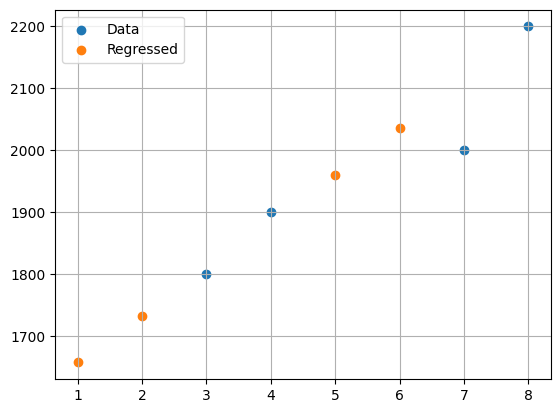

In [10]:
fig, axe = plt.subplots()
axe.scatter(data.loc[~q, "Day"], data.loc[~q, "Price"], label="Data")
axe.scatter(data.loc[q, "Day"], data.loc[q, "Price"], label="Regressed")
axe.legend()
axe.grid()